<a href="https://colab.research.google.com/github/alakaramkesh/Character-Level-GPT/blob/main/LLM_Poem_creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
! pip install torch

# ***Building the Model:***

In [79]:
import json
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [81]:
!ls /content
# if you do not see these three files: train_ids.npy  val_ids.npy	vocab.json , please upload them

drive  sample_data  train_ids.npy  val_ids.npy	vocab.json


Read the files created in the last step. (the .npy ones and the vocab .json file)

In [82]:
base = Path("/content")

with open(base / "vocab.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)
# loading the numpy arrays of corpus
train_ids = np.load(base / "train_ids.npy")
val_ids = np.load(base / "val_ids.npy")
# turn np arrays to tensor
train_ids = torch.tensor(train_ids, dtype=torch.long)
val_ids = torch.tensor(val_ids, dtype=torch.long)
print("vocab size:", len(vocab["stoi"]))
print("train shape:", train_ids.shape)
print("val shape:", val_ids.shape)

vocab size: 46
train shape: torch.Size([607786])
val shape: torch.Size([70512])


Here the method creates batches of input and output.
(Shifting the gold output by one character)

In [83]:
def get_batch(split, train_ids, val_ids, batch_size, context_len, device):
    data = train_ids if split == "train" else val_ids
    ix = torch.randint(0, len(data) - context_len - 1, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix]) # shifting x by one position
    return x.to(device), y.to(device)

Causal self-attention layer with two options: manual masked attention or PyTorch SDPA.

In [84]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1, attention_mode="sdpa"):
        super().__init__()
        #checks
        assert d_model % n_heads == 0
        assert attention_mode in ["sdpa", "manual"]

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.attention_mode = attention_mode

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def _shape(self, x, B, T):
        # (B, T, C) -> (B, H, T, D)
        return x.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

    # traditional approach based on masked attention with a triangular causal mask
    def _manual_attention(self, q, k, v, x):
        B, H, T, D = q.shape
        # raw attention scores
        scores = q @ k.transpose(-2, -1)   # (B, H, T, T)
        # scale
        scores = scores / math.sqrt(D)
        # causal mask
        mask = torch.tril(
            torch.ones(T, T, device=x.device, dtype=torch.bool)
        )
        scores = scores.masked_fill(~mask, float("-inf"))
        # normalize
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights) # prevent overfitting
        # weighted sum of values
        attn_out = attn_weights @ v   # (B, H, T, D)
        return attn_out

    # torch.nn.functional.scaled_dot_product_attention
    def _sdpa_attention(self, q, k, v):
        return F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.attn_dropout.p if self.training else 0.0,
            is_causal=True
        )

    def forward(self, x):
        B, T, C = x.shape
        # build Q, K, V
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        # split into heads
        q = self._shape(q, B, T)
        k = self._shape(k, B, T)
        v = self._shape(v, B, T)
        # choose attention implementation
        if self.attention_mode == "manual":
            attn_out = self._manual_attention(q, k, v, x)
        else:
            attn_out = self._sdpa_attention(q, k, v)
        # merge heads: (B, H, T, D) -> (B, T, C)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        # final output projection
        out = self.out_proj(attn_out)
        out = self.resid_dropout(out)
        return out

Here is the class for the feed forward layer of the architecture.

In [85]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()

        if d_ff is None:
            d_ff = 4 * d_model

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

A single Transformer block with Pre-LN, causal self-attention, and a feed-forward network.

In [86]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1, attention_mode="sdpa"):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(
            d_model=d_model,
            n_heads=n_heads,
            dropout=dropout,
            attention_mode=attention_mode
        )

        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(
            d_model=d_model,
            d_ff=d_ff,
            dropout=dropout
        )

    def forward(self, x):
        # Pre-LN attention + residual
        x = x + self.attn(self.ln1(x))
        # Pre-LN FFN + residual
        x = x + self.ff(self.ln2(x))
        return x

# ***Training the Model***
The main class is the CharGPT class.

In [87]:
class CharGPT(nn.Module):
    def __init__(
        self,
        vocab_size,
        context_len,
        d_model,
        n_heads,
        n_layers,
        d_ff=None,
        dropout=0.1,
        attention_mode="sdpa"
    ):
        super().__init__()
        self.context_len = context_len
        self.d_model = d_model
        # token embedding: maps each character id to a vector
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # learned positional embedding
        self.pos_emb = nn.Embedding(context_len, d_model)
        # stack of transformer blocks
        self.blocks = nn.Sequential(*[
            TransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout,
                attention_mode=attention_mode
            )
            for _ in range(n_layers)
        ])
        # final layer norm
        self.ln_f = nn.LayerNorm(d_model)
        # output projection to vocabulary size
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None):
        # idx shape: (B, T)
        B, T = idx.shape
        assert T <= self.context_len, "Sequence length is bigger than block size"
        # positions: [0, 1, 2, ..., T-1]
        pos = torch.arange(0, T, device=idx.device)
        # token embeddings: (B, T, d_model)
        tok = self.token_emb(idx)
        # positional embeddings: (T, d_model)
        pos = self.pos_emb(pos)
        # broadcast add -> (B, T, d_model)
        x = tok + pos
        # pass through transformer blocks
        x = self.blocks(x)
        # final layer norm
        x = self.ln_f(x)
        # logits over vocabulary: (B, T, vocab_size)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(B * T, -1),
                targets.view(B * T)
            )
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        self.eval()
        for _ in range(max_new_tokens):
            # Keep only the last context_len tokens
            idx_cond = idx[:, -self.context_len:]
            # Forward pass
            logits, _ = self(idx_cond)
            # Take logits of the last time step
            logits = logits[:, -1, :]
            # Apply temperature
            logits = logits / temperature
            # Optional top-k filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")
            # Convert to probabilities
            probs = torch.softmax(logits, dim=-1)
            # Sample next token
            next_token = torch.multinomial(probs, num_samples=1)
            # Append to sequence
            idx = torch.cat((idx, next_token), dim=1)
        self.train()
        return idx

` BASE HYPERPARAMETERS:`

In [88]:
base_config = {
    "d_model": 256,
    "n_heads": 8,
    "n_layers": 6,
    "dropout": 0.1,
    "batch_size": 32,
    "context_len": 256,
    "learning_rate": 3e-4,
    "weight_decay": 0.1,
    "max_steps": 10000,
    "log_interval": 100,
    "eval_interval": 200,
    "eval_iters": 10,
    "sample_interval": 1000,
    "checkpoint_interval": 1000,
    "warmup_steps": 500,
    "attention_mode": "sdpa",
}

In [89]:
def estimate_loss(model, train_ids, val_ids, batch_size, context_len, device, eval_iters=20):
    out = {}
    model.eval() # switch to evaluation mode
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split, train_ids, val_ids, batch_size, context_len, device)
            with torch.no_grad(): # disable gradient tracking here
                logits, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train() # back to training mode
    return out

# Convert loss to bits-per-character
def loss_to_bpc(loss):
    return loss / math.log(2)

In [90]:
# Convert text → token IDs
def encode(text, stoi):
    unk_id = stoi.get("<unk>", None)
    ids = []
    for ch in text:
        if ch in stoi:
            ids.append(stoi[ch])
        elif unk_id is not None:
            ids.append(unk_id)
        else:
            raise ValueError(f"Unknown character: {repr(ch)}")
    return ids

# Convert token IDs → text
def decode(ids, itos):
    if isinstance(itos, list):
        return "".join(itos[i] for i in ids)
    return "".join(itos[str(i)] for i in ids)

# Generate text from a prompt using the model
def generate_text(model, prompt, stoi, itos, device, max_new_tokens=300, temperature=1.0, top_k=20):
    was_training = model.training
    model.eval()
    start_ids = encode(prompt, stoi)
    if len(start_ids) == 0:
        start_ids = [stoi["\n"]] if "\n" in stoi else [0]
    x = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        y = model.generate(
            x,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k
        )

    text = decode(y[0].tolist(), itos)
    # Restore original mode
    if was_training:
        model.train()
    return text

NOW TRAIN:

and also monitor what is happening

In [91]:
from google.colab import drive
drive.mount('/content/drive')
project_dir = "/content/drive/MyDrive/llm_poem_project"
os.makedirs(project_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
def run_experiment(exp_name, config, train_ids, val_ids, vocab, device):
    # Create a folder for this experiment inside Google Drive(I will have to change this later)
    run_dir = os.path.join(project_dir, "experiments", exp_name)
    os.makedirs(run_dir, exist_ok=True)

    # Read vocabulary objects
    stoi = vocab["stoi"]
    itos = vocab["itos"]
    vocab_size = len(stoi)

    # Read hyperparameters from config
    d_model = config["d_model"]
    n_heads = config["n_heads"]
    n_layers = config["n_layers"]
    dropout = config["dropout"]
    batch_size = config["batch_size"]
    context_len = config["context_len"]
    learning_rate = config["learning_rate"]
    weight_decay = config["weight_decay"]
    max_steps = config["max_steps"]
    log_interval = config["log_interval"]
    eval_interval = config["eval_interval"]
    eval_iters = config["eval_iters"]
    sample_interval = config["sample_interval"]
    checkpoint_interval = config["checkpoint_interval"]
    warmup_steps = config["warmup_steps"]
    attention_mode = config["attention_mode"]

    # Build the model
    model = CharGPT(
        vocab_size=vocab_size,
        context_len=context_len,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=4 * d_model,
        dropout=dropout,
        attention_mode=attention_mode
    ).to(device)

    # Create optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # for logs and generated samples
    history = []
    samples = []
    best_val_loss = float("inf")
    running_loss = 0.0
    start_time = time.time()

    # Linear warm-up for the learning rate
    def get_lr(step):
        if step < warmup_steps:
            return learning_rate * (step + 1) / warmup_steps
        return learning_rate

    model.train()

    for step in range(max_steps):
        # Update learning rate
        lr = get_lr(step)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        # Get a batch of training data
        xb, yb = get_batch(
            "train",
            train_ids=train_ids,
            val_ids=val_ids,
            batch_size=batch_size,
            context_len=context_len,
            device=device
        )

        # Forward pass
        _, loss = model(xb, yb)

        # Backward pass and parameter update
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print average training loss every few steps
        if (step + 1) % log_interval == 0:
            avg_train_loss = running_loss / log_interval
            elapsed = time.time() - start_time
            print(
                f"[{exp_name}] step {step+1}/{max_steps} | "
                f"avg train loss = {avg_train_loss:.4f} | "
                f"lr = {lr:.6f} | time = {elapsed:.1f}s"
            )
            running_loss = 0.0

        # Run evaluation on train/validation
        if (step + 1) % eval_interval == 0:
            losses = estimate_loss(
                model=model,
                train_ids=train_ids,
                val_ids=val_ids,
                batch_size=batch_size,
                context_len=context_len,
                device=device,
                eval_iters=eval_iters
            )

            train_bpc = loss_to_bpc(losses["train"])
            val_bpc = loss_to_bpc(losses["val"])

            history.append({
                "step": step + 1,
                "train_loss": losses["train"],
                "val_loss": losses["val"],
                "train_bpc": train_bpc,
                "val_bpc": val_bpc,
                "lr": lr,
            })

            print(
                f"[{exp_name}] [eval] step {step+1} | "
                f"train loss = {losses['train']:.4f} | "
                f"val loss = {losses['val']:.4f} | "
                f"train bpc = {train_bpc:.4f} | "
                f"val bpc = {val_bpc:.4f}"
            )

            # Save the best model according to validation loss
            if losses["val"] < best_val_loss:
                best_val_loss = losses["val"]
                torch.save({
                    "step": step + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": losses["val"],
                    "config": config,
                }, os.path.join(run_dir, "best_model.pt"))

        # Generate text samples during training
        if (step + 1) % sample_interval == 0:
            sample_text = generate_text(
                model=model,
                prompt="\n",
                stoi=stoi,
                itos=itos,
                device=device,
                max_new_tokens=400,
                temperature=1.0,
                top_k=20
            )

            print(f"\n--- SAMPLE [{exp_name}] step {step+1} ---\n")
            print(sample_text)
            print("\n------------------------------\n")

            samples.append({
                "step": step + 1,
                "prompt": "\n",
                "temperature": 1.0,
                "top_k": 20,
                "text": sample_text,
            })

        # Save a checkpoint regularly
        if (step + 1) % checkpoint_interval == 0:
            torch.save({
                "step": step + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
            }, os.path.join(run_dir, f"checkpoint_step_{step+1}.pt"))

    total_time = time.time() - start_time

    # Save training history
    with open(os.path.join(run_dir, "history.json"), "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    # Save generated samples in json format
    with open(os.path.join(run_dir, "samples.json"), "w", encoding="utf-8") as f:
        json.dump(samples, f, ensure_ascii=False, indent=2)

    # Save generated samples in a readable text file
    with open(os.path.join(run_dir, "samples.txt"), "w", encoding="utf-8") as f:
        for s in samples:
            f.write(f"=== step {s['step']} ===\n")
            f.write(s["text"])
            f.write("\n\n")

    # Save a short summary of the experiment
    summary = {
        "exp_name": exp_name,
        "config": config,
        "best_val_loss": best_val_loss,
        "total_time_sec": total_time,
    }

    with open(os.path.join(run_dir, "summary.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    return summary


> TESTING HYPERPARAMETERS:


In [93]:
import os
import json

all_summaries = []

for context_len in [128, 256, 512]:
    # Copy base config to avoid modifying it
    cfg = base_config.copy()
    cfg["context_len"] = context_len

    exp_name = f"context_{context_len}"
    run_dir = os.path.join(project_dir, "experiments", exp_name)
    summary_path = os.path.join(run_dir, "summary.json")

    # If experiment already exists, skip training
    if os.path.exists(summary_path):
        print(f"Skipping {exp_name}: files already exist.")
        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)

    # Otherwise, run experiment
    else:
        summary = run_experiment(
            exp_name=exp_name,
            config=cfg,
            train_ids=train_ids,
            val_ids=val_ids,
            vocab=vocab,
            device=device
        )

    all_summaries.append(summary)

print("Context experiments finished or loaded successfully.")

Skipping context_128: files already exist.
Skipping context_256: files already exist.
Skipping context_512: files already exist.
Context experiments finished or loaded successfully.


TESTING ANOTHER HYPERPARAMETER

In [94]:
import os
import json

all_summaries = []

for n_layers in [4, 6, 8]:
    # Make a copy of the base configuration
    cfg = base_config.copy()
    cfg["context_len"] = 256
    cfg["n_layers"] = n_layers

    # Give each layers experiment its own unique name
    exp_name = f"layers_{n_layers}"
    run_dir = os.path.join(project_dir, "experiments", exp_name)
    summary_path = os.path.join(run_dir, "summary.json")

    # If this experiment already exists, do not run it again
    if os.path.exists(summary_path):
        print(f"Skipping {exp_name}: files already exist.")
        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)

    # Otherwise, run the experiment and save new files
    else:
        summary = run_experiment(
            exp_name=exp_name,
            config=cfg,
            train_ids=train_ids,
            val_ids=val_ids,
            vocab=vocab,
            device=device
        )

    all_summaries.append(summary)

Skipping layers_4: files already exist.
Skipping layers_6: files already exist.
Skipping layers_8: files already exist.


The plots:

In [95]:
import matplotlib.pyplot as plt

def load_history(exp_name): #loading the files for plotting
    path = os.path.join(project_dir, "experiments", exp_name, "history.json")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def plot_experiments(exp_names, title):
    plt.figure()

    for exp in exp_names:
        history = load_history(exp)
        steps = [h["step"] for h in history]
        val_loss = [h["val_loss"] for h in history]

        plt.plot(steps, val_loss, label=exp)

    plt.xlabel("Steps")
    plt.ylabel("Validation Loss")
    plt.title(title)
    plt.legend()
    plt.show()


> FOR CONTEXT_LEN HYPERPARAMETER:


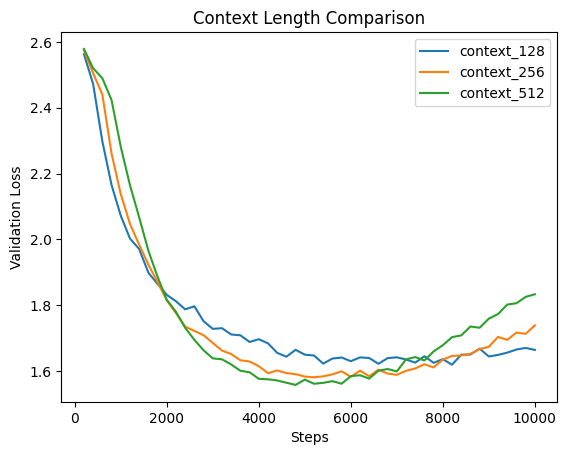

In [96]:
plot_experiments(
    ["context_128", "context_256", "context_512"],
    "Context Length Comparison"
)

> FOR N_LAYERS HYPERPARAMETER:

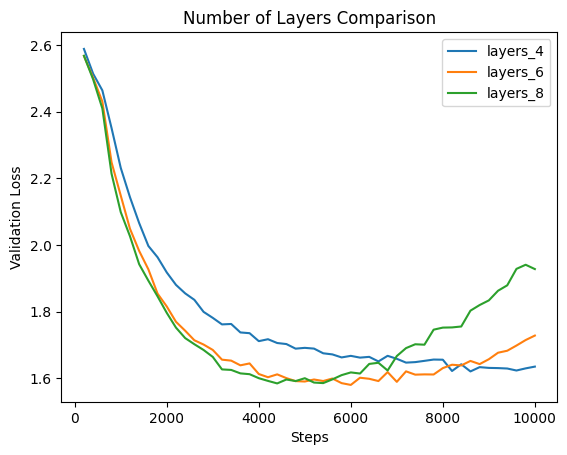

In [97]:
plot_experiments(
    ["layers_4", "layers_6", "layers_8"],
    "Number of Layers Comparison"
)

STAGE IV: Analysing the Poems Generated by the Model



> First load the best model




In [98]:
# Choose the experiment we want to analyze
exp_name = "context_256"
# Path to the experiment folder
run_dir = os.path.join(project_dir, "experiments", exp_name)
# Path to best checkpoint
ckpt_path = os.path.join(run_dir, "best_model.pt")
# Load checkpoint
checkpoint = torch.load(ckpt_path, map_location=device)
# Read config directly from checkpoint
config = checkpoint["config"]
print("Loaded config from checkpoint:")
print(json.dumps(config, ensure_ascii=False, indent=2))

# Read vocabulary
stoi = vocab["stoi"]
itos = vocab["itos"]
vocab_size = len(stoi)

# Rebuild the model with the same hyperparameters
model = CharGPT(
    vocab_size=vocab_size,
    context_len=config["context_len"],
    d_model=config["d_model"],
    n_heads=config["n_heads"],
    n_layers=config["n_layers"],
    d_ff=4 * config["d_model"],
    dropout=config["dropout"],
    attention_mode=config["attention_mode"]
).to(device)
# Load model weights
model.load_state_dict(checkpoint["model_state_dict"])
# Switch to evaluation mode
model.eval()
# sanity checks
print(f"Best model for '{exp_name}' loaded successfully.")
print(f"Checkpoint step: {checkpoint['step']}")
print(f"Validation loss: {checkpoint['val_loss']:.4f}")

Loaded config from checkpoint:
{
  "d_model": 256,
  "n_heads": 8,
  "n_layers": 6,
  "dropout": 0.1,
  "batch_size": 32,
  "context_len": 256,
  "learning_rate": 0.0003,
  "weight_decay": 0.1,
  "max_steps": 10000,
  "log_interval": 100,
  "eval_interval": 200,
  "eval_iters": 10,
  "sample_interval": 1000,
  "checkpoint_interval": 1000,
  "warmup_steps": 500,
  "attention_mode": "sdpa"
}
Best model for 'context_256' loaded successfully.
Checkpoint step: 5200
Validation loss: 1.5810




> Now, we create Some prompts from the training corpus



In [99]:
import random
def extract_prompts_from_corpus(text, num_prompts=12, min_chars=30, max_chars=100, seed=42):
    # Extract short prompts from the training corpus.
    random.seed(seed)
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    prompts = []
    for line in lines:
        if min_chars <= len(line) <= max_chars:
            prompts.append(line)
    random.shuffle(prompts)
    return prompts[:num_prompts]

In [100]:
train_text = decode(train_ids.tolist(), itos)
prompts = extract_prompts_from_corpus(
    train_text,
    num_prompts=30,
    min_chars=30,
    max_chars=100,
    seed=42
)

print("Number of prompts:", len(prompts))

Number of prompts: 30



> Now we generate using multiple settings:



In [101]:
generation_settings = [
    {"name": "temp_07_topk_20", "temperature": 0.7, "top_k": 20},
    {"name": "temp_10_topk_40", "temperature": 1.0, "top_k": 40},
    {"name": "temp_12_topk_40", "temperature": 1.2, "top_k": 40},
]

In [108]:
def generate_poem_collection(
    model,
    prompts,
    stoi,
    itos,
    device,
    settings,
    num_poems_per_setting=20,
    max_new_tokens=300,
    seed=42
):
    """
    Generate poems and also concatenate all poems per setting.
    """
    random.seed(seed)

    results = []
    setting_texts = {}

    for setting in settings:
        setting_name = setting["name"]
        setting_texts[setting_name] = []

        for _ in range(num_poems_per_setting):
            prompt = random.choice(prompts)

            generated_text = generate_text(
                model=model,
                prompt=prompt,
                stoi=stoi,
                itos=itos,
                device=device,
                max_new_tokens=max_new_tokens,
                temperature=setting["temperature"],
                top_k=setting["top_k"]
            )

            results.append({
                "setting_name": setting_name,
                "temperature": setting["temperature"],
                "top_k": setting["top_k"],
                "prompt": prompt,
                "generated_text": generated_text
            })

            setting_texts[setting_name].append(generated_text)

    # Join all poems of each setting into one big text
    setting_texts = {
        name: "\n\n\n".join(texts)
        for name, texts in setting_texts.items()
    }

    return results, setting_texts



> Now we start the analysing part:
checking if the generated text reproduces the same statistical regularities



In [119]:
def extract_structural_features(text):
    """
    Extract structural features from corpus text.
    - poems are separated by \n\n\n
    - stanzas inside a poem are separated by \n\n
    - lines are separated by \n
    """
    text = text.strip()
    all_lines = text.splitlines()
    raw_stanzas = text.split("\n\n")
    # Keep only non-empty lines
    non_empty_lines = [line for line in all_lines if line.strip()]
    # Build a clean list of stanzas, each stanza is a list of non-empty lines
    stanzas = [
        [line for line in stanza.split("\n") if line.strip()]
        for stanza in raw_stanzas
        if stanza.strip()
    ]

    # Character length of each non-empty line
    line_lengths_chars = [len(line) for line in non_empty_lines]
    # Word count of each non-empty line
    line_lengths_words = [len(line.split()) for line in non_empty_lines]
    # Number of lines in each stanza
    stanza_lengths = [len(stanza) for stanza in stanzas]
    # Last 2 characters of each line
    line_endings_2 = [line[-2:] if len(line) >= 2 else line for line in non_empty_lines]
    # Last 3 characters of each line
    line_endings_3 = [line[-3:] if len(line) >= 3 else line for line in non_empty_lines]
    # Count blank lines
    blank_line_count = len(all_lines) - len(non_empty_lines)
    # Ratio of blank lines over all lines
    blank_line_ratio = blank_line_count / max(1, len(all_lines))  # avoid divide by zero
    # Return all extracted features in one dictionary
    return {
        "line_lengths_chars": line_lengths_chars,
        "line_lengths_words": line_lengths_words,
        "stanza_lengths": stanza_lengths,
        "line_endings_2": line_endings_2,
        "line_endings_3": line_endings_3,
        "blank_line_ratio": blank_line_ratio,
        "num_lines": len(non_empty_lines),
        "num_stanzas": len(stanzas)
    }

In [109]:
generated_poems, setting_texts = generate_poem_collection(
    model=model,
    prompts=prompts,
    stoi=stoi,
    itos=itos,
    device=device,
    settings=generation_settings
)

In [118]:
setting_features = {
    name: extract_structural_features(text)
    for name, text in setting_texts.items()
}
train_features = extract_structural_features(train_text)

In [120]:
import pandas as pd

summary_rows = []

# Add train corpus row
summary_rows.append({
    "source": "train_corpus",
    "mean_line_chars": float(np.mean(train_features["line_lengths_chars"])),
    "std_line_chars": float(np.std(train_features["line_lengths_chars"])),
    "mean_line_words": float(np.mean(train_features["line_lengths_words"])),
    "mean_stanza_len": float(np.mean(train_features["stanza_lengths"])),
    "blank_line_ratio": train_features["blank_line_ratio"],
    "num_lines": train_features["num_lines"],
    "num_stanzas": train_features["num_stanzas"]
})

# Add one row per setting
for name, feats in setting_features.items():
    summary_rows.append({
        "source": name,
        "mean_line_chars": float(np.mean(feats["line_lengths_chars"])),
        "std_line_chars": float(np.std(feats["line_lengths_chars"])),
        "mean_line_words": float(np.mean(feats["line_lengths_words"])),
        "mean_stanza_len": float(np.mean(feats["stanza_lengths"])),
        "blank_line_ratio": feats["blank_line_ratio"],
        "num_lines": feats["num_lines"],
        "num_stanzas": feats["num_stanzas"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,source,mean_line_chars,std_line_chars,mean_line_words,mean_stanza_len,blank_line_ratio,num_lines,num_stanzas
0,train_corpus,30.793709,4.458145,7.233168,1.999255,0.356607,18789,9398
1,temp_07_topk_20,33.395833,7.188647,8.255208,1.745455,0.419940,192,110
2,temp_10_topk_40,32.979381,6.841323,8.015464,1.747748,0.419162,194,111
3,temp_12_topk_40,31.428571,7.249160,7.201970,1.845455,0.411594,203,110


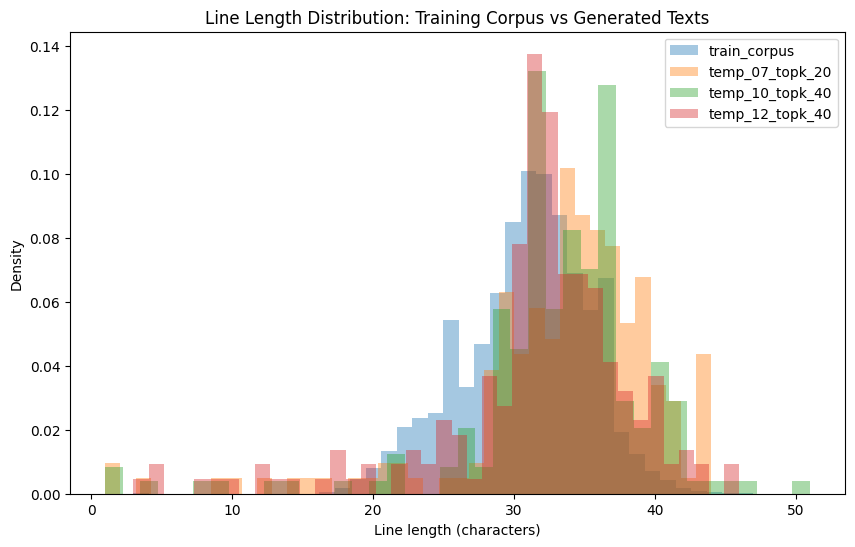

In [121]:

plt.figure(figsize=(10, 6))

plt.hist(
    train_features["line_lengths_chars"],
    bins=40,
    alpha=0.4,
    density=True,
    label="train_corpus"
)

for name, feats in setting_features.items():
    plt.hist(
        feats["line_lengths_chars"],
        bins=40,
        alpha=0.4,
        density=True,
        label=name
    )

plt.xlabel("Line length (characters)")
plt.ylabel("Density")
plt.title("Line Length Distribution: Training Corpus vs Generated Texts")
plt.legend()
plt.show()

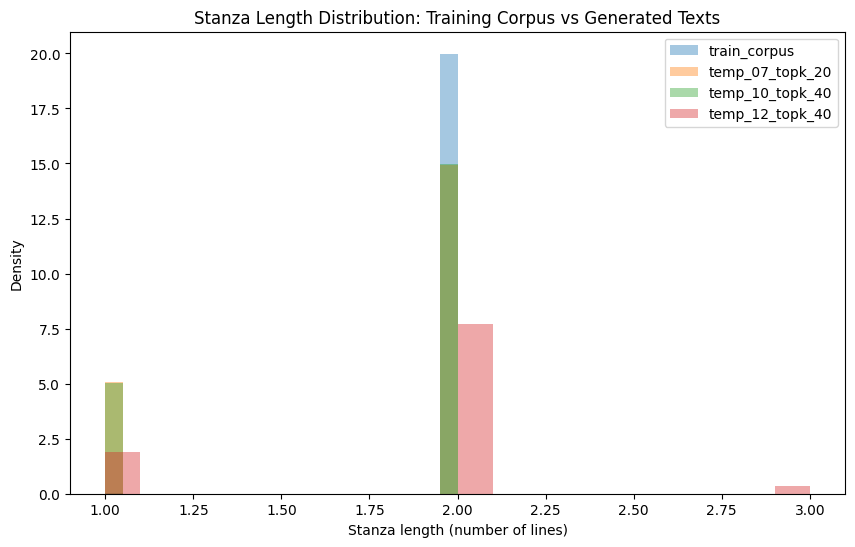

In [122]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_features["stanza_lengths"],
    bins=20,
    alpha=0.4,
    density=True,
    label="train_corpus"
)

for name, feats in setting_features.items():
    plt.hist(
        feats["stanza_lengths"],
        bins=20,
        alpha=0.4,
        density=True,
        label=name
    )

plt.xlabel("Stanza length (number of lines)")
plt.ylabel("Density")
plt.title("Stanza Length Distribution: Training Corpus vs Generated Texts")
plt.legend()
plt.show()

In [123]:
for i, item in enumerate(generated_poems[:6], 1):
    print(f"\n{'=' * 90}")
    print(f"Example {i}")
    print(f"Setting: {item['setting_name']}")
    print("\n--- Prompt ---")
    print(item["prompt"])
    print("\n--- Generated text ---")
    print(item["generated_text"])


Example 1
Setting: temp_07_topk_20

--- Prompt ---
از دگری چه حاصلم تا ز تو مهر بگسلم

--- Generated text ---
از دگری چه حاصلم تا ز تو مهر بگسلم
از دست بندگی بازنشینم می‌کنی


دوش در پای تو پادشاهی می‌کند
به تو من می‌رسد و تو آن خواهی می‌کند

به خوبان نرسد هزار دل می‌کنند
به دست مستی که می‌رسد به کاهی می‌کند

دعوی از دست تو نیز در دست آیین حافظ
به دوستی نمی‌کند مرا به همچنانی می‌کند

به جان می‌رفتم از تو دوستان می‌کنند
که در این خانه او را 

Example 2
Setting: temp_07_topk_20

--- Prompt ---
میان این همه خواهندگان به من چه رسد

--- Generated text ---
میان این همه خواهندگان به من چه رسد


من از ما به یاد من آمد صورت دوستیم
بگوی ما را که در همه عالم من چه رسد

از آن چه زرد ساز درمان به دست نگیرم
که در سر زلف بوستان چه غم در سر گاهرت دوستیم

به وصال دریا که سگ دوست بدین هم برآید
که اگر چه بر سر سر خود گذری همت دوستیم

ز آن خاک من ز پای تو به دست و نامه نمی‌بینم
که تو بریزم که بر سر 

Example 3
Setting: temp_07_topk_20

--- Prompt ---
با همه آتش زبانی در تو گیراییم نیست

--- Generated tex